In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
rng = np.random.default_rng(345)

# Simulated Downsampling Correlation Scatter

- far just kept old, but can use new and change title / font size 

In [13]:
mu1 = 10
mu2 = 10
s1 = 5
s2 = 5

M = 100
N = 10
n = 100

m = 0.25

if m == 0:
    beta = np.ones(n)
else:
    b = (1 / m) - 1
    beta = rng.beta(1, b, size=n)

corr_OG = []
corr_OB = []

for rho in np.linspace(-1, 1, M):

    Sigma = np.array([
        [s1**2, rho*s1*s2],
        [rho*s1*s2, s2**2]
    ])
    mu = np.array([mu1, mu2])

    for i in range(N):

        x_OG = rng.multivariate_normal(mu, Sigma, size=n)
        x_OG = x_OG.astype(np.int64)
        
        x_OG[x_OG < 0] = 0
        
        x_OB = rng.binomial(x_OG, beta[:, None])

        rho_OG = np.corrcoef(x_OG.T)[0, 1]
        rho_OB = np.corrcoef(x_OB.T)[0, 1]
        
        corr_OG.append(rho_OG)
        corr_OB.append(rho_OB)

In [48]:
plt.rcParams.update({'font.size': 20})

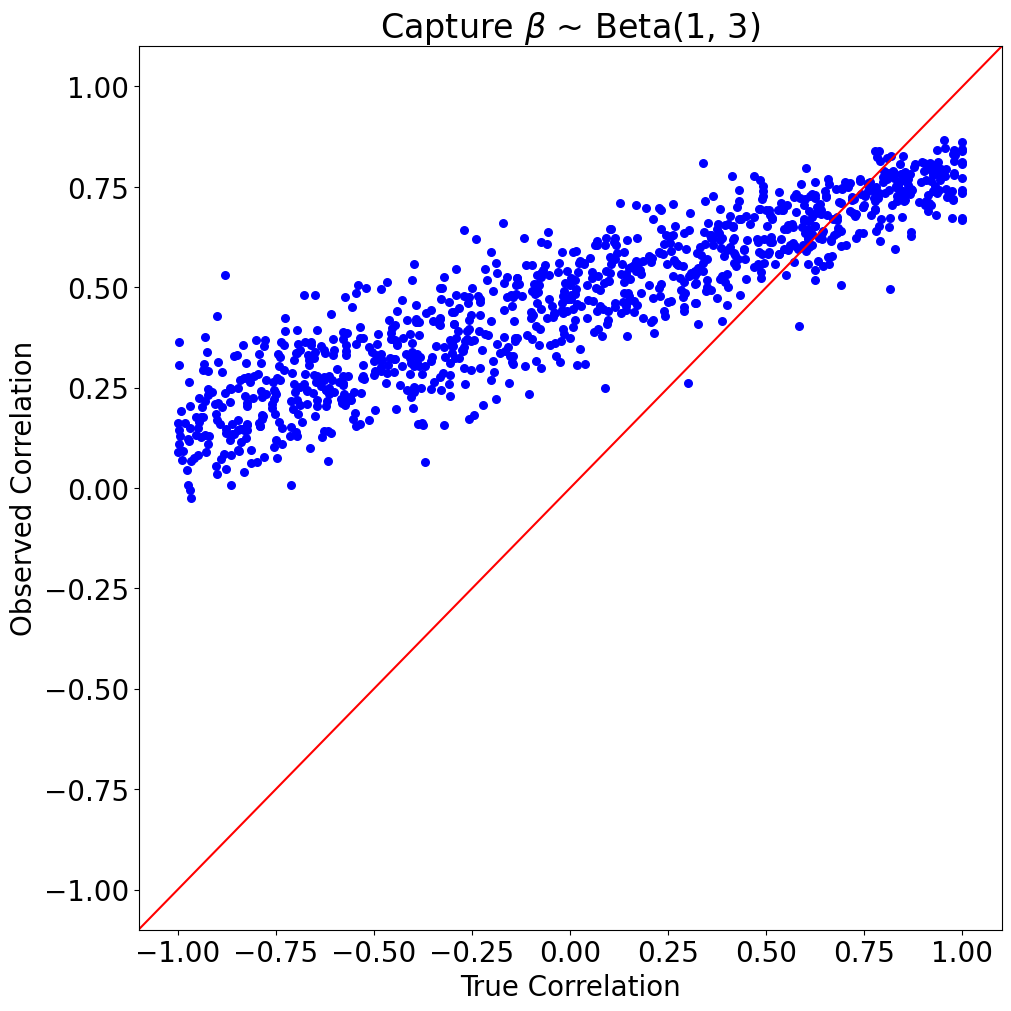

In [71]:
fig, axs = plt.subplots(figsize=(10, 10), constrained_layout=True)
axs.scatter(corr_OG, corr_OB, color="blue", s=30)
axs.axline([-1]*2, [1]*2, color="red")
axs.set_xlabel("True Correlation")
axs.set_ylabel("Observed Correlation")
#axs.set_xticks([-1.0, -0.5, 0, 0.5, 1.0])
#axs.set_xticklabels(["-1.00", "-0.50", "0.00", "0.50", "1.00"])
axs.set_title(r"Capture $\beta$ ~ Beta(1, 3)")
plt.show()

In [ ]:
#fig.savefig("correlationScatterLargeText.svg")

# FIB Observed vs Recovered histograms

## Result organization & consistency

In [74]:
MF_ind_d3_df = pd.read_csv("Results/d3/independent_MF.csv", index_col=0)
MF_ind_d4_df = pd.read_csv("Results/d4/independent_MF.csv", index_col=0)

MF_int_d3_df = pd.read_csv("Results/d3/interacting_MF.csv", index_col=0)
MF_int_d4_df = pd.read_csv("Results/d4/interacting_MF.csv", index_col=0)

corr_df = pd.read_csv("Results/d3/correlation.csv", index_col=0)

In [75]:
MF_ind_df_old_1 = pd.read_csv("../../Moment-equations/Real-Data-2/Results/independent_MF.csv", index_col=0)
MF_ind_df_old_2 = pd.read_csv("../../Latent-Experiments/Cell-Cycle-Investigation/Results/independent_MF_concat.csv", index_col=0)

In [76]:
MF_int_df_old_1 = pd.read_csv("../../Moment-equations/Real-Data-2/Results/interacting_MF.csv", index_col=0)
MF_int_df_old_2 = pd.read_csv("../../Latent-Experiments/Cell-Cycle-Investigation/Results/interacting_MF_concat.csv", index_col=0)

In [137]:
# compare the 3 results
v1 = MF_ind_df_old_1["MIR222_d3_c95_status"]
v2 = MF_ind_df_old_2["MIR222_All_d3_c95_status"]
v3 = MF_ind_d3_df["MIR222_status"]

# seems consistent (will vary due to bootstrap, etc)
pd.concat([v1, v2, v3], axis=1).value_counts()

MIR222_d3_c95_status  MIR222_All_d3_c95_status  MIR222_status
OPTIMAL               OPTIMAL                   OPTIMAL          9208
INFEASIBLE            INFEASIBLE                INFEASIBLE         69
OPTIMAL               INFEASIBLE                INFEASIBLE          6
INFEASIBLE            INFEASIBLE                OPTIMAL             5
                      OPTIMAL                   OPTIMAL             4
OPTIMAL               OPTIMAL                   INFEASIBLE          2
INFEASIBLE            OPTIMAL                   INFEASIBLE          1
OPTIMAL               INFEASIBLE                OPTIMAL             1
Name: count, dtype: int64

In [140]:
v1.value_counts().iloc[1], v2.value_counts().iloc[1], v3.value_counts().iloc[1]

(np.int64(79), np.int64(81), np.int64(78))

## Plot

In [232]:
idxs = [6, 7, 15]
miRNA_list = ["MIR222", "MIR23A", "MIR877"]

In [233]:
# use "Real Data 2" (old 1) independence results for d = 2, 3, 4
# use new H&R midpoints at d = 3 for all

OB = []
OB_d2 = []
OB_d3 = []
OB_d4 = []

AL_d2 = []
AL_d3 = []
AL_d4 = []

HAR_d2 = []
HAR_d3 = []
HAR_d4 = []

for miRNA in miRNA_list:

    OB += corr_df[f'{miRNA}_OB'].tolist()

    mask = (MF_ind_df_old_1[f'{miRNA}_d2_c95_status'] == "INFEASIBLE")
    OB_d2 += corr_df[f'{miRNA}_OB'][mask].tolist()
    AL_d2 += corr_df[f'{miRNA}_AL'][mask].tolist()
    HAR_d2 += MF_int_d3_df[f'{miRNA}_HAR_mid'][mask].dropna().tolist()

    mask = (MF_ind_df_old_1[f'{miRNA}_d3_c95_status'] == "INFEASIBLE")
    OB_d3 += corr_df[f'{miRNA}_OB'][mask].tolist()
    AL_d3 += corr_df[f'{miRNA}_AL'][mask].tolist()
    HAR_d3 += MF_int_d3_df[f'{miRNA}_HAR_mid'][mask].dropna().tolist()

    mask = (MF_ind_df_old_1[f'{miRNA}_d4_c95_status'] == "INFEASIBLE")
    OB_d4 += corr_df[f'{miRNA}_OB'][mask].tolist()
    AL_d4 += corr_df[f'{miRNA}_AL'][mask].tolist()
    HAR_d4 += MF_int_d3_df[f'{miRNA}_HAR_mid'][mask].dropna().tolist()

In [234]:
plt.rcParams.update({'font.size': 16})

In [249]:
colours = ["blue", "green", "red"]

### Seaborn

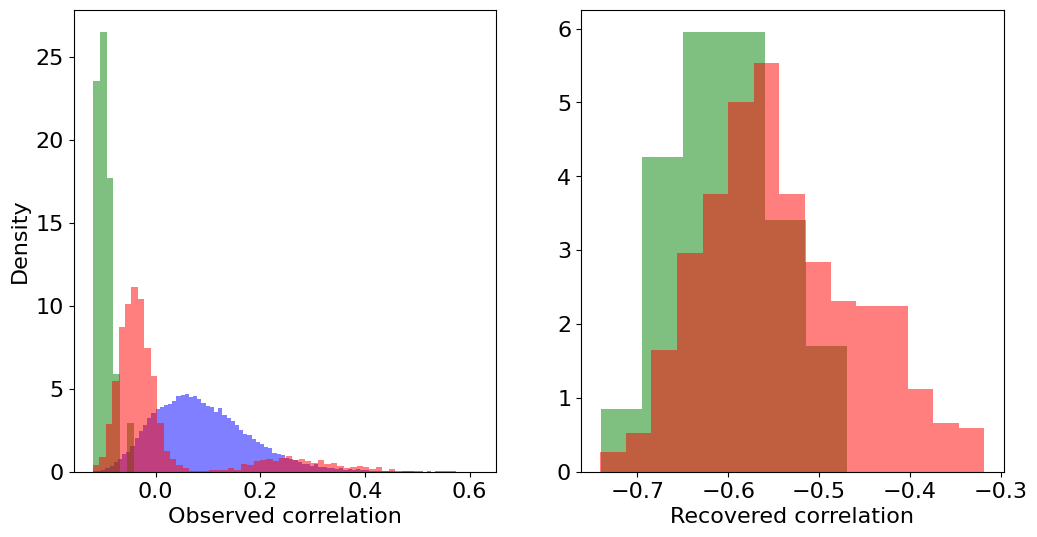

In [250]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# ------------------------------------------------------------------------------
# Observed correlation
# ------------------------------------------------------------------------------

# all pairs
L = len(OB)
bins = int(np.sqrt(L))
sns.histplot(x=OB, color=colours[0], alpha=0.5, stat="density", element="step", lw=0, ax=axs[0])

# interacting order d = 2
d = 2
L = len(OB_d2)
bins = int(np.sqrt(L))
sns.histplot(x=OB_d2, color=colours[1], alpha=0.5, stat="density", element="step", lw=0, ax=axs[0])

# interacting order d = 3
d = 3
L = len(OB_d3)
bins = int(np.sqrt(L))
#sns.histplot(x=OB_d3, color="green", alpha=0.5, stat="density", element="step", lw=0, ax=axs[0])

# interacting order d = 4
d = 4
L = len(OB_d4)
bins = int(np.sqrt(L))
sns.histplot(x=OB_d4, color=colours[2], bins=bins, alpha=0.5, stat="density", element="step", lw=0, ax=axs[0])

axs[0].set_xlabel("Observed correlation")
axs[0].set_ylabel("Density")

# ------------------------------------------------------------------------------
# Recovered correlation: HAR midpoint
# ------------------------------------------------------------------------------

# interacting order d = 2
d = 2
L = len(HAR_d2)
bins = int(np.sqrt(L))
sns.histplot(x=HAR_d2, color=colours[1], alpha=0.5, stat="density", element="step", lw=0, ax=axs[1])

# interacting order d = 3
d = 3
L = len(HAR_d3)
bins = int(np.sqrt(L))
#sns.histplot(x=HAR_d3, color="green", alpha=0.5, stat="density", element="step", lw=0, ax=axs[1])

# interacting order d = 4
d = 4
L = len(HAR_d4)
bins = int(np.sqrt(L))
sns.histplot(x=HAR_d4, color=colours[2], alpha=0.5, stat="density", element="step", lw=0, ax=axs[1])

axs[1].set_xlabel("Recovered correlation")
axs[1].set_ylabel("")

#axs[1].set_xlim(left=-1, right=1)

plt.show()

In [ ]:
#fig.savefig("FIBObservedRecoveredHist.svg")

### Matplotlib

Allows scaling of bar heights, but can't use svg due to vertical lines

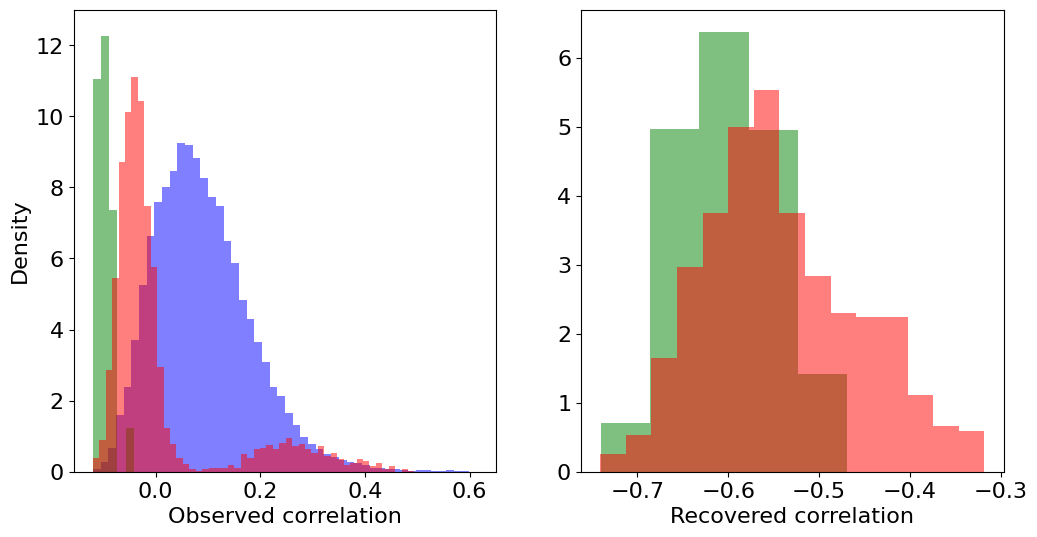

In [185]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# ------------------------------------------------------------------------------
# Observed correlation
# ------------------------------------------------------------------------------

# all pairs
L = len(OB)
bins = int(np.sqrt(L))
bins = 50
#sns.histplot(x=OB, color="blue", alpha=0.5, stat="density", element="step", lw=0, ax=axs[0])
_, _, rects = axs[0].hist(OB, color="blue", bins=bins, alpha=0.5, density=True, linewidth=0.0)
for r in rects:
    r.set_height(r.get_height() * 2)

# interacting order d = 2
d = 2
L = len(OB_d2)
bins = int(np.sqrt(L))
#sns.histplot(x=OB_d2, color="green", alpha=0.5, stat="density", element="step", lw=0, ax=axs[0])
_, _, rects = axs[0].hist(OB_d2, color="green", bins=bins, alpha=0.5, density=True, linewidth=0.0)
for r in rects:
    r.set_height(r.get_height() / 2)

# interacting order d = 3
d = 3
L = len(OB_d3)
bins = int(np.sqrt(L))
#sns.histplot(x=OB_d3, color="green", alpha=0.5, stat="density", element="step", lw=0, ax=axs[0])
#axs[0].hist(OB_d3, color="green", bins=bins, alpha=0.5, density=True, linewidth=0.0)

# interacting order d = 4
d = 4
L = len(OB_d4)
bins = int(np.sqrt(L))
#sns.histplot(x=OB_d4, color="red", bins=bins, alpha=0.5, stat="density", element="step", lw=0, ax=axs[0])
axs[0].hist(OB_d4, color="red", bins=bins, alpha=0.5, density=True, linewidth=0.0)

axs[0].set_xlabel("Observed correlation")
axs[0].set_ylabel("Density")

# ------------------------------------------------------------------------------
# Recovered correlation: HAR midpoint
# ------------------------------------------------------------------------------

# interacting order d = 2
d = 2
L = len(HAR_d2)
bins = int(np.sqrt(L))
#sns.histplot(x=HAR_d2, color="green", alpha=0.5, stat="density", element="step", lw=0, ax=axs[1])
axs[1].hist(HAR_d2, color="green", bins=bins, alpha=0.5, density=True, linewidth=0.0)

# interacting order d = 3
d = 3
L = len(HAR_d3)
bins = int(np.sqrt(L))
#sns.histplot(x=HAR_d3, color="green", alpha=0.5, stat="density", element="step", lw=0, ax=axs[1])
#axs[1].hist(HAR_d3, color="green", bins=bins, alpha=0.5, density=True, linewidth=0.0)

# interacting order d = 4
d = 4
L = len(HAR_d4)
bins = int(np.sqrt(L))
bins = 15
#sns.histplot(x=HAR_d4, color="red", alpha=0.5, stat="density", element="step", lw=0, ax=axs[1])
axs[1].hist(HAR_d4, color="red", bins=bins, alpha=0.5, density=True, linewidth=0.0)

axs[1].set_xlabel("Recovered correlation")
axs[1].set_ylabel("")

axs[0].set_ylim(top=13)
#axs[1].set_xlim(left=-1, right=1)

plt.show()

In [ ]:
#fig.savefig("FIBObservedRecoveredHistScaled.svg")

In [ ]:
#fig.savefig("FIBObservedRecoveredHistScaled.png", dpi=300)

# FIB Network Graphs

In [190]:
import igraph as ig

In [278]:
MF_ind_df = pd.read_csv("Results/d3/independent_MF.csv", index_col=0)
MF_int_df = pd.read_csv("Results/d3/interacting_MF.csv", index_col=0)
corr_df = pd.read_csv("Results/d3/correlation.csv", index_col=0)

In [279]:
# extract names of miRNA analysed
miRNA_names = [col.split("_")[0] for col in MF_ind_df.columns]

## Observed correlations

In [280]:
# get observed interacting mask, and observed correlations
int_mask = np.zeros(MF_ind_df.shape).astype(bool)
for i, miRNA in enumerate(miRNA_names):
    lb = corr_df[f'{miRNA}_OB_min']
    ub = corr_df[f'{miRNA}_OB_max']
    mask = (lb < 0) & (ub > 0)
    int_mask[:, i] = mask
corrs = corr_df[[f'{miRNA}_OB' for miRNA in miRNA_names]].values

# reduce in size
M = 100
G = 5
int_mask = int_mask[:M, :G]
corrs = corrs[:M, :G]

# reduce to mRNA with [k, K] interations
k = 2
K = 10
mRNA_mask = (int_mask.sum(axis=1) >= k) & (int_mask.sum(axis=1) <= K)
int_mask = int_mask[mRNA_mask, :]
corrs = corrs[mRNA_mask, :]

# reduce to mRNA with at least d correlations above threshold t
d = 2
t = 0.1
mRNA_mask = (((corrs > t) | (corrs < -t)).sum(axis=1) >= d)
int_mask = int_mask[mRNA_mask, :]
corrs = corrs[mRNA_mask, :]

# size
N_mRNA, N_miRNA = int_mask.shape

# construct edges
idxs = np.where(int_mask)
edges = [(int(j), N_miRNA + int(i)) for i, j in zip(*idxs)]

# get edge correlations
corrs = corrs[idxs]

In [281]:
# total vertices
vertices = N_miRNA + N_mRNA

# color, label, size different for miRNA vs mRNA
vertex_color = ["orange"] * N_miRNA + ["black"] * N_mRNA
vertex_size = [30] * N_miRNA + [10] * N_mRNA
vertex_label = miRNA_names[:G] + [None] * N_mRNA

# edge width: constant or can relate to correlation strength
edge_width = [2 for c in corrs] # int(abs(c) * 10)

# edge color: red for negative, blue for positive, alpha of strength
edge_color = [(1, 0, 0, -c) if c < 0 else (0, 0, 1, c) for c in corrs]

# display size
print(f"{len(edges)} edges between {vertices} vertices")

# construct graph
g = ig.Graph(vertices, edges)

134 edges between 40 vertices


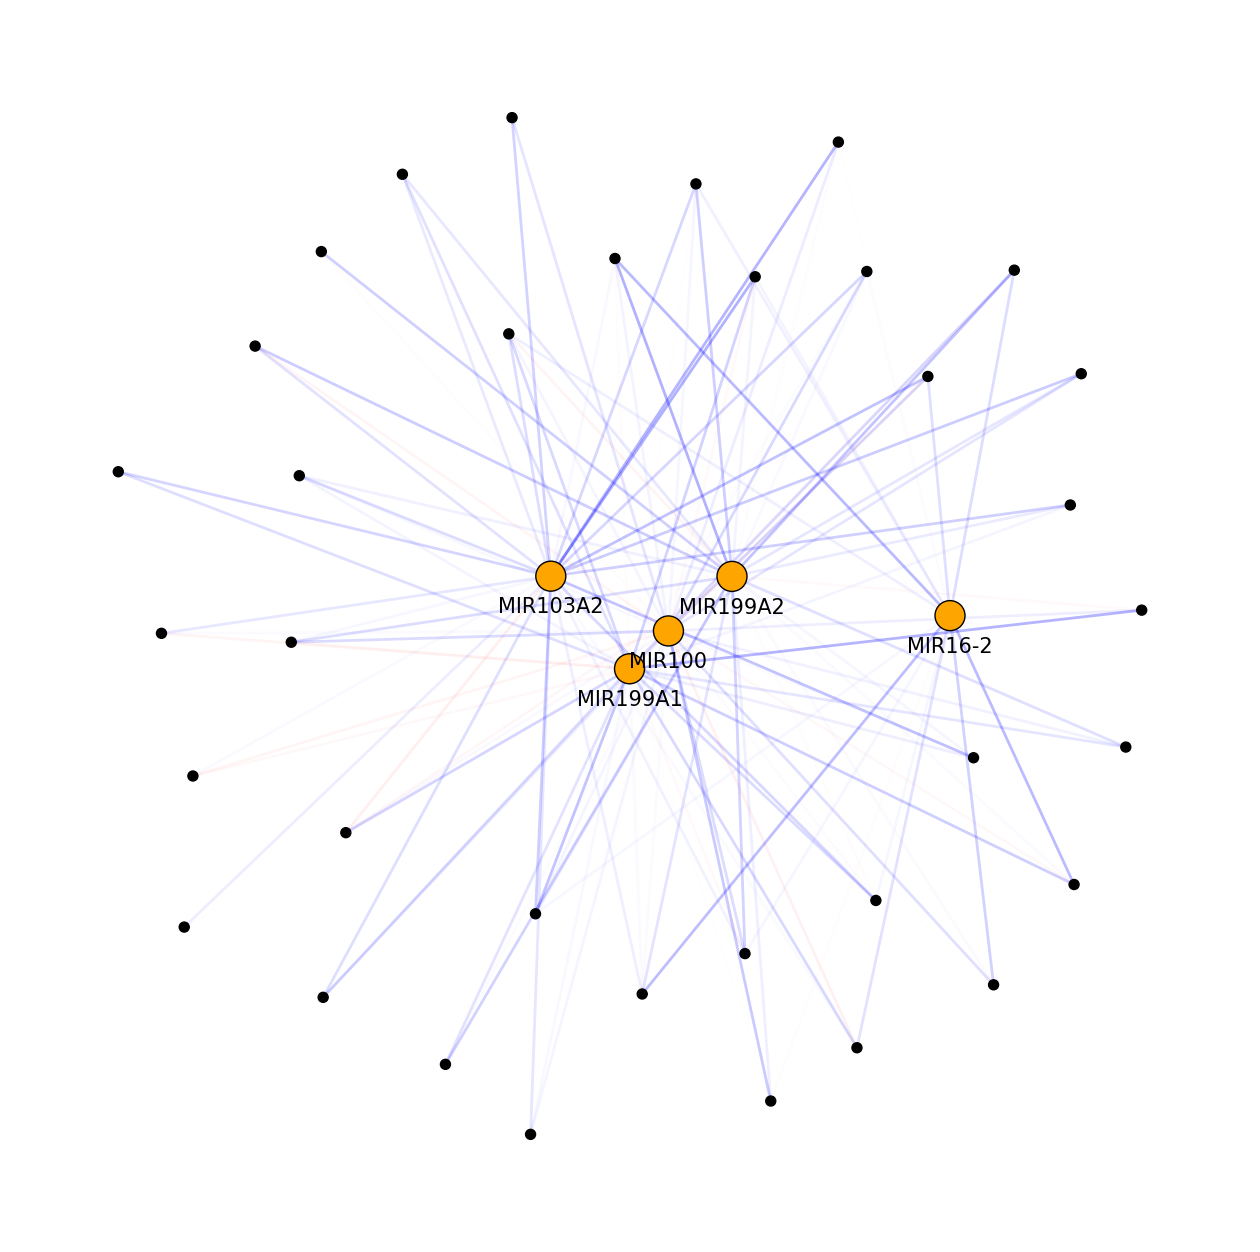

In [282]:
fig, axs = plt.subplots(figsize=(16, 16))
ig.plot(
    g,
    target=axs,
    #layout="large", # node layout algorithm
    vertex_size=vertex_size,
    vertex_color=vertex_color,
    vertex_frame_width=1,
    vertex_label=vertex_label,
    vertex_label_size=15,
    vertex_label_dist=1.5,
    edge_width=edge_width,
    edge_color=edge_color
)
plt.show()

In [ ]:
#fig.savefig("FIBObservedNetwork.svg")

## Recovered correlations

In [284]:
# get interacting mask and correlations
int_mask = (MF_ind_df == "INFEASIBLE").values
corrs = MF_int_df[[f'{miRNA}_HAR_mid' for miRNA in miRNA_names]].values

# reduce in size
M = 100
G = 5
int_mask = int_mask[:M, :G]
corrs = corrs[:M, :G]

# reduce to mRNA with [k, K] interations
k = 2
K = 10
mRNA_mask = (int_mask.sum(axis=1) >= k) & (int_mask.sum(axis=1) <= K)
int_mask = int_mask[mRNA_mask, :]
corrs = corrs[mRNA_mask, :]

# reduce to mRNA with at least d correlations above threshold t
d = 2
t = 0.1
mRNA_mask = (((corrs > t) | (corrs < -t)).sum(axis=1) >= d)
int_mask = int_mask[mRNA_mask, :]
corrs = corrs[mRNA_mask, :]

# size
N_mRNA, N_miRNA = int_mask.shape

# construct edges
idxs = np.where(int_mask)
edges = [(int(j), N_miRNA + int(i)) for i, j in zip(*idxs)]

# get edge correlations
corrs = corrs[idxs]

In [285]:
# total vertices
vertices = N_miRNA + N_mRNA

# color, label, size different for miRNA vs mRNA
vertex_color = ["orange"] * N_miRNA + ["black"] * N_mRNA
vertex_size = [30] * N_miRNA + [10] * N_mRNA
vertex_label = miRNA_names[:G] + [None] * N_mRNA

# edge width: constant or can relate to correlation strength
edge_width = [2 for c in corrs] # int(abs(c) * 10)

# edge color: red for negative, blue for positive, alpha of strength
edge_color = [(1, 0, 0, -c) if c < 0 else (0, 0, 1, c) for c in corrs]

# display size
print(f"{len(edges)} edges between {vertices} vertices")

# construct graph
g = ig.Graph(vertices, edges)

41 edges between 22 vertices


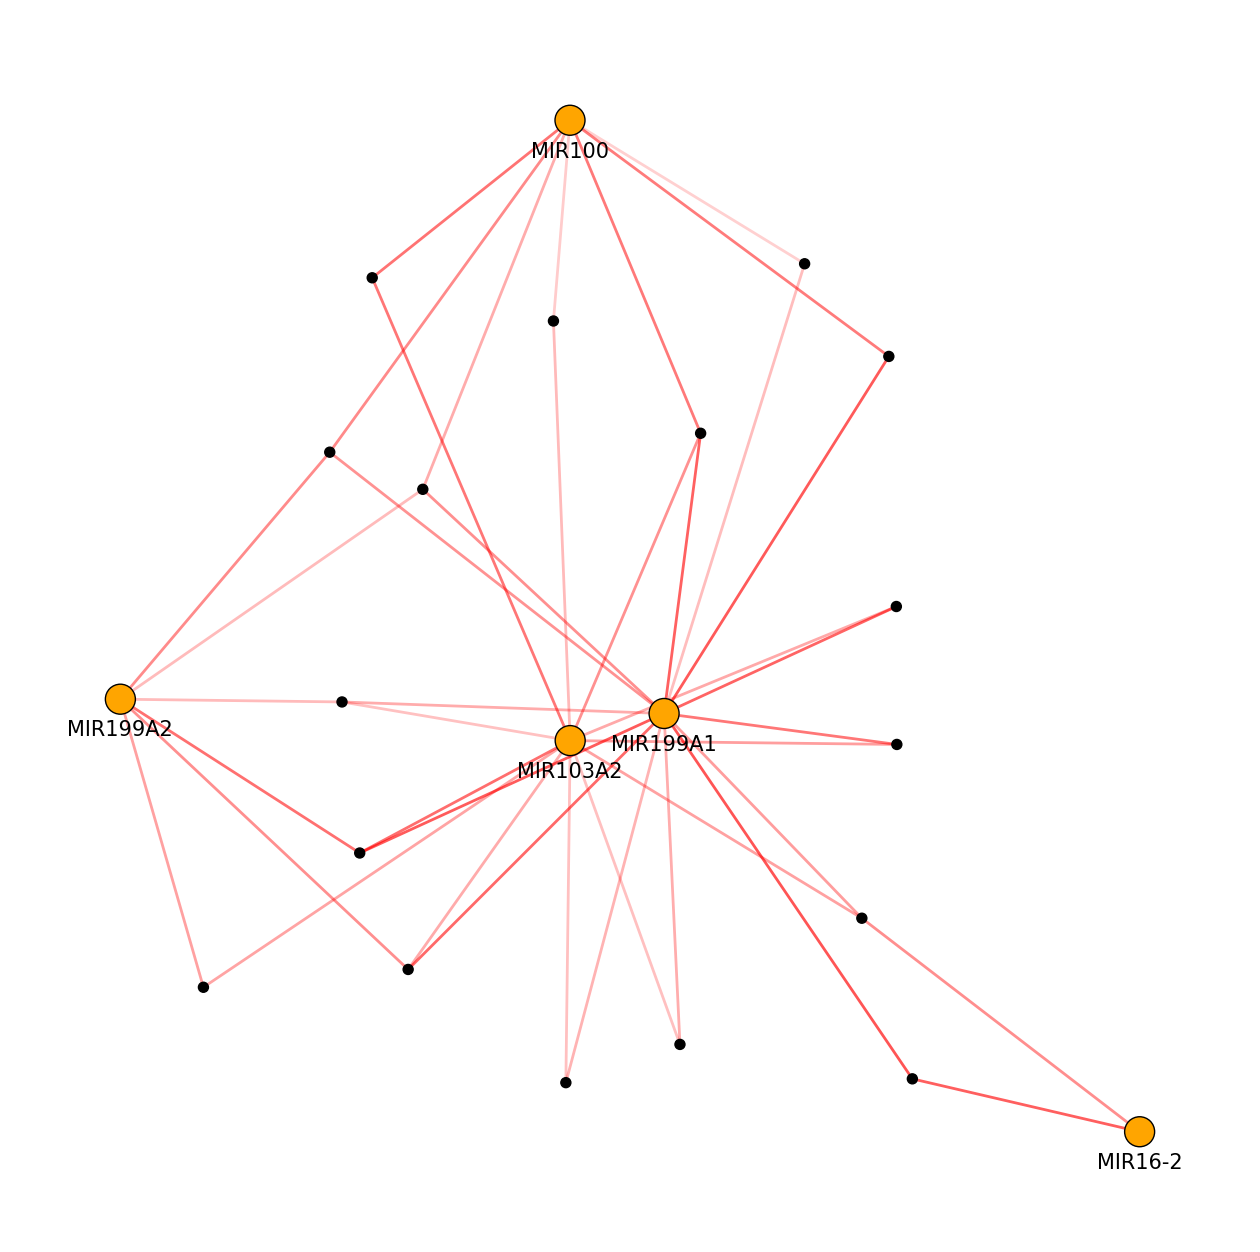

In [286]:
fig, axs = plt.subplots(figsize=(16, 16))
ig.plot(
    g,
    target=axs,
    #layout="large", # node layout algorithm
    vertex_size=vertex_size,
    vertex_color=vertex_color,
    vertex_frame_width=1,
    vertex_label=vertex_label,
    vertex_label_size=15,
    vertex_label_dist=1.5,
    edge_width=edge_width,
    edge_color=edge_color
)
plt.show()

In [ ]:
#fig.savefig("FIBRecoveredNetwork.svg")